Dataset Loaded Successfully
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_reno

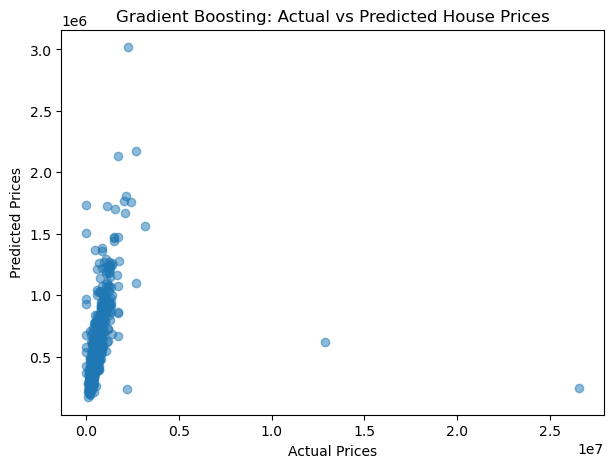


Task Completed Successfully!


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

df = pd.read_csv("/Users/shahzorali/Downloads/archive 2/data.csv")
print("Dataset Loaded Successfully")
print(df.head())

#  PREPROCESSING

# Convert date to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Extract meaningful time features
df["house_age"] = df["date"].dt.year - df["yr_built"]
df["renovated"] = df["yr_renovated"].apply(lambda x: 1 if x > 0 else 0)

# Extract zipcode from "statezip"
df["zipcode"] = df["statezip"].str.extract(r"(\d+)", expand=False)

# Features selected (as required by assignment: size, bedrooms, location)
numeric_features = [
    "sqft_living",
    "sqft_lot",
    "bedrooms",
    "bathrooms",
    "floors",
    "sqft_above",
    "sqft_basement",
    "house_age",
    "renovated"
]

categorical_features = ["city", "zipcode"]

target = "price"

X = df[numeric_features + categorical_features]
y = df[target]


preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)


# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# MODEL 1: LINEAR REGRESSION


lr_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# LR Metrics
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("\n===== Linear Regression Results =====")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)

#  MODEL 2: GRADIENT BOOSTING REGRESSOR


gbr_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", GradientBoostingRegressor())
])

gbr_model.fit(X_train, y_train)
gbr_pred = gbr_model.predict(X_test)

# GBR Metrics
gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))

print("\n===== Gradient Boosting Results =====")
print("MAE:", gbr_mae)
print("RMSE:", gbr_rmse)


plt.figure(figsize=(7,5))
plt.scatter(y_test, gbr_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Gradient Boosting: Actual vs Predicted House Prices")
plt.show()

print("\nTask Completed Successfully!")
